## COVID Drivers: Data Preparation

### Table of Contents
* [Read the Data](#read)</BR>
* [Histograms and Normalicy Tests](#normal)</BR>
* [Natural Log Transformation)](#nlog)</BR>
* [Square Root Transformation](#sqrt)</BR>
* [Reciprocal transformation](#recip)</BR>
* [BoxCox Transformation](#bxcx)</BR>
* [Special Handling of NHTSA_AGG_DRIVING](#nhtsa)</BR>
* [Final BoxCox Trasnformation All Columns](#final)</BR>



Import packages

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from scipy.stats import normaltest, boxcox, yeojohnson

In [2]:
# Import project specific utilities
from utils.functions import *

In [3]:
path_in = 'data/ready/'
flags_in = 'flags_dataset.csv'
full_in = 'full_dataset.csv'

### <a id='read'>Read the data</a>

Read dataset created in covid_drivers_05_Prep.ipynb

In [4]:
df_init = pd.read_csv(path_in + flags_in, low_memory=False)

In [5]:
df_init.head()

,CRN,CRASH_DATE,AGGRESSIVE_DRIVING,NHTSA_AGG_DRIVING,NO_CLEARANCE,RUNNING_RED_LT,RUNNING_STOP_SIGN,SPEEDING,SPEEDING_RELATED,TAILGATING,POST_COVID
0,2005000003,2005-01-01,1,0,0,0,0,0,1,0,0
1,2005000006,2005-01-01,1,0,0,0,0,0,1,0,0
2,2005000010,2005-01-01,1,0,0,0,0,1,1,0,0
3,2005000012,2005-01-01,1,0,1,0,0,0,0,0,0
4,2005000013,2005-01-01,0,0,0,0,0,0,0,0,0


In [6]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 2460484 entries, 0 to 2460483
Data columns (total 11 columns):
 #   Column              Dtype
---  ------              -----
 0   CRN                 int64
 1   CRASH_DATE          str  
 2   AGGRESSIVE_DRIVING  int64
 3   NHTSA_AGG_DRIVING   int64
 4   NO_CLEARANCE        int64
 5   RUNNING_RED_LT      int64
 6   RUNNING_STOP_SIGN   int64
 7   SPEEDING            int64
 8   SPEEDING_RELATED    int64
 9   TAILGATING          int64
 10  POST_COVID          int64
dtypes: int64(10), str(1)
memory usage: 206.5 MB


In [7]:
df_init['CRASH_DATE'] = pd.to_datetime(df_init['CRASH_DATE'])

In [8]:
summ_idx = df_init.copy().set_index('CRASH_DATE').drop(columns=['CRN'])

In [9]:
summ_idx.head()

,AGGRESSIVE_DRIVING,NHTSA_AGG_DRIVING,NO_CLEARANCE,RUNNING_RED_LT,RUNNING_STOP_SIGN,SPEEDING,SPEEDING_RELATED,TAILGATING,POST_COVID
CRASH_DATE,,,,,,,,,
2005-01-01,1,0,0,0,0,0,1,0,0
2005-01-01,1,0,0,0,0,0,1,0,0
2005-01-01,1,0,0,0,0,1,1,0,0
2005-01-01,1,0,1,0,0,0,0,0,0
2005-01-01,0,0,0,0,0,0,0,0,0


In [10]:
df = summ_idx.copy().resample('MS').mean()

In [11]:
post_df = df.loc[df['POST_COVID']==1].copy()
pre_df = df.loc[df['POST_COVID']==0].copy()

In [12]:
all_cols = ['AGGRESSIVE_DRIVING',
 'NHTSA_AGG_DRIVING', 
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING']

In [13]:
behav_cols = ['NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING']

### <a id='normal'>Histograms and Normalicy Tests</a>

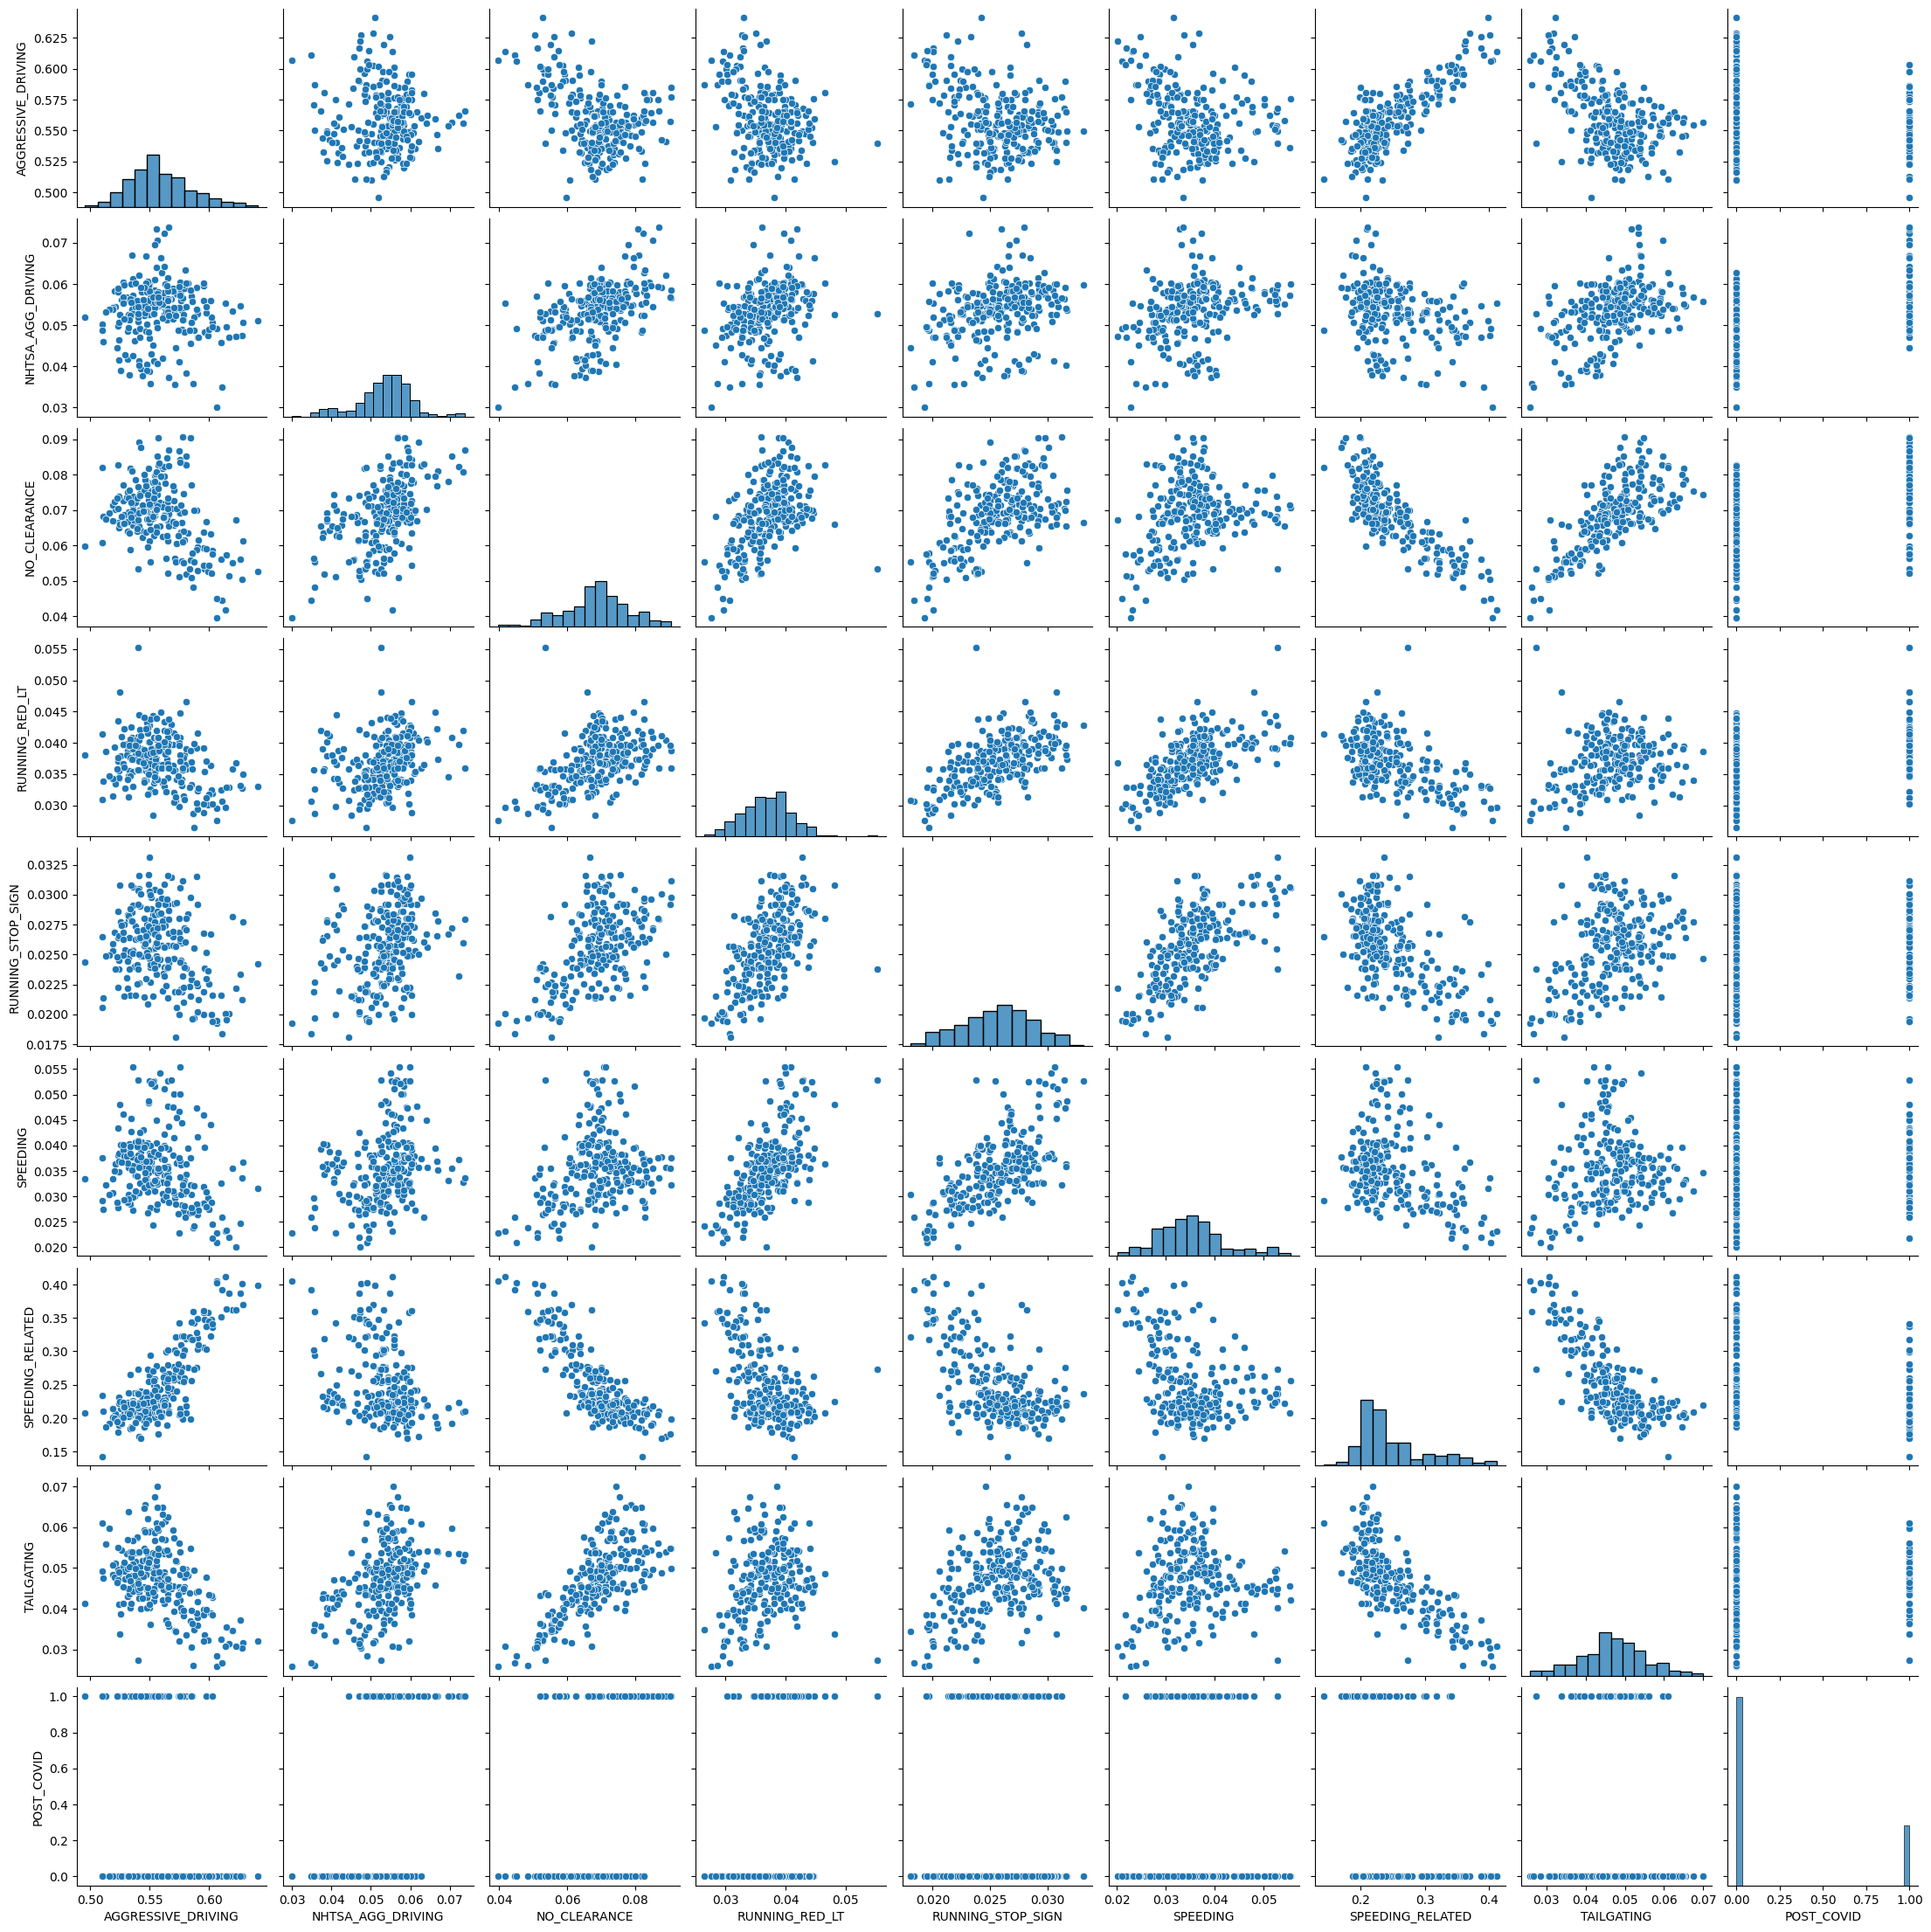

In [14]:
sns.pairplot(df)
plt.show()

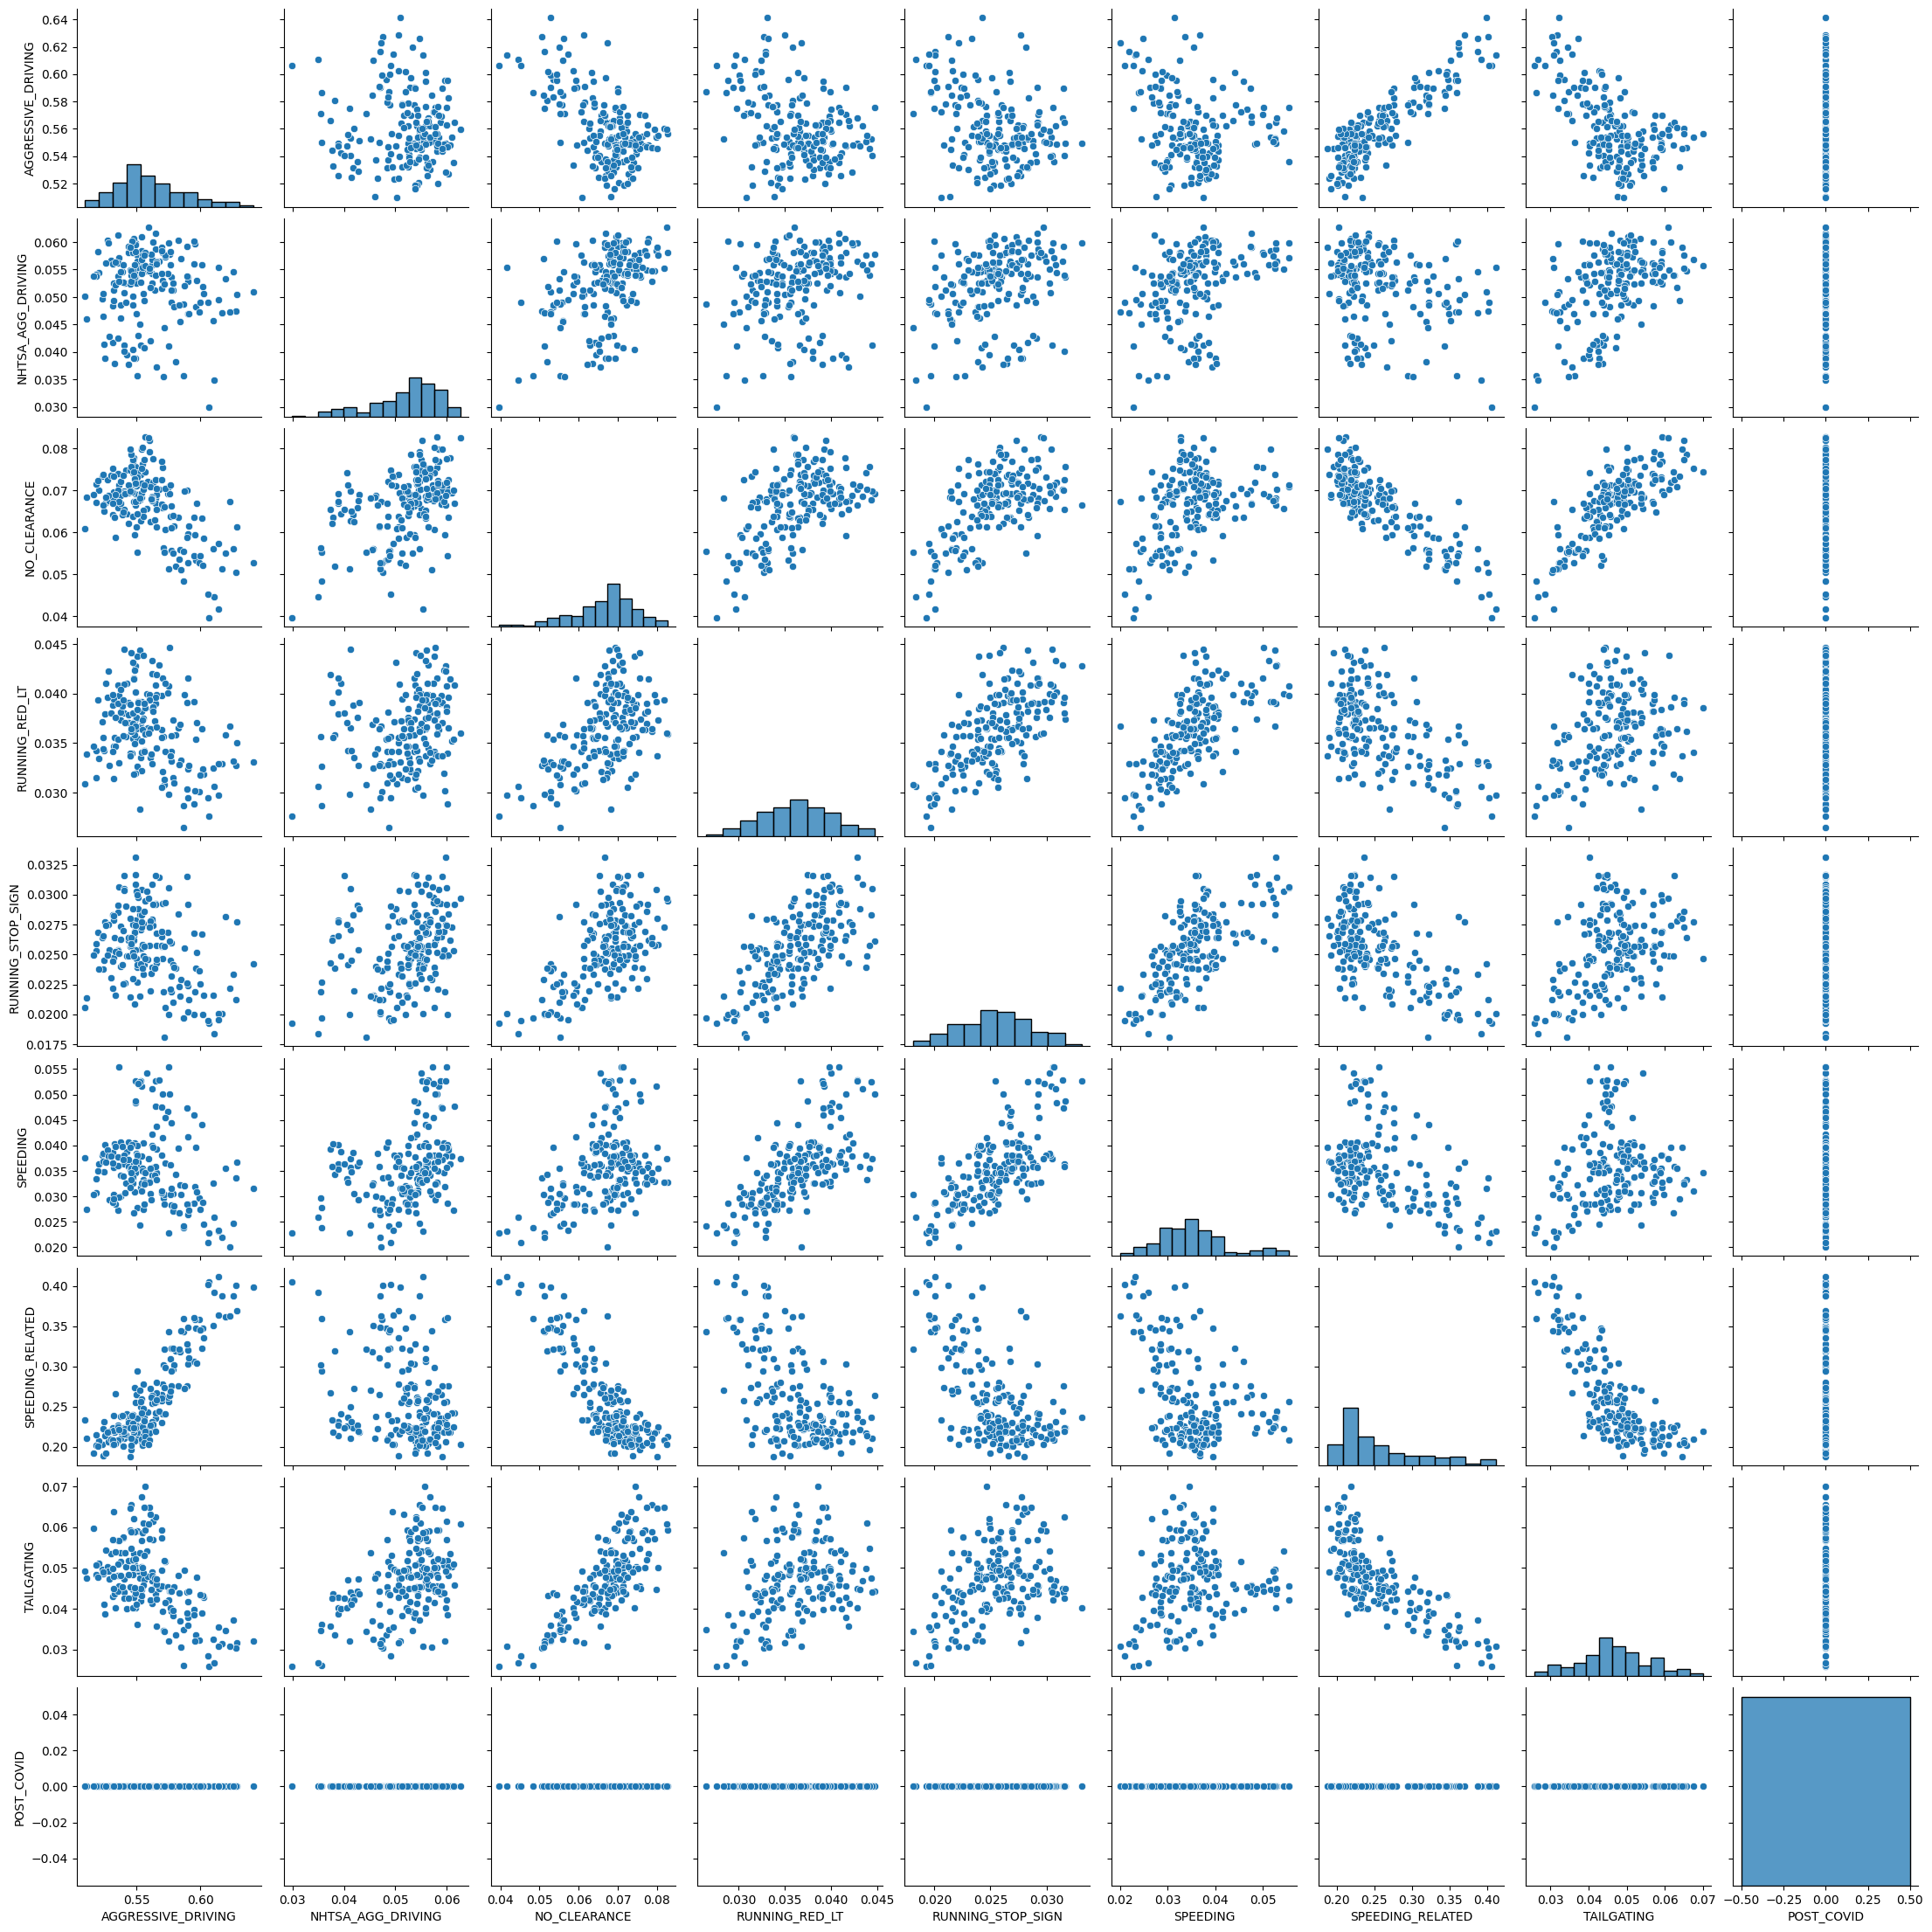

In [15]:
sns.pairplot(pre_df)
plt.show()

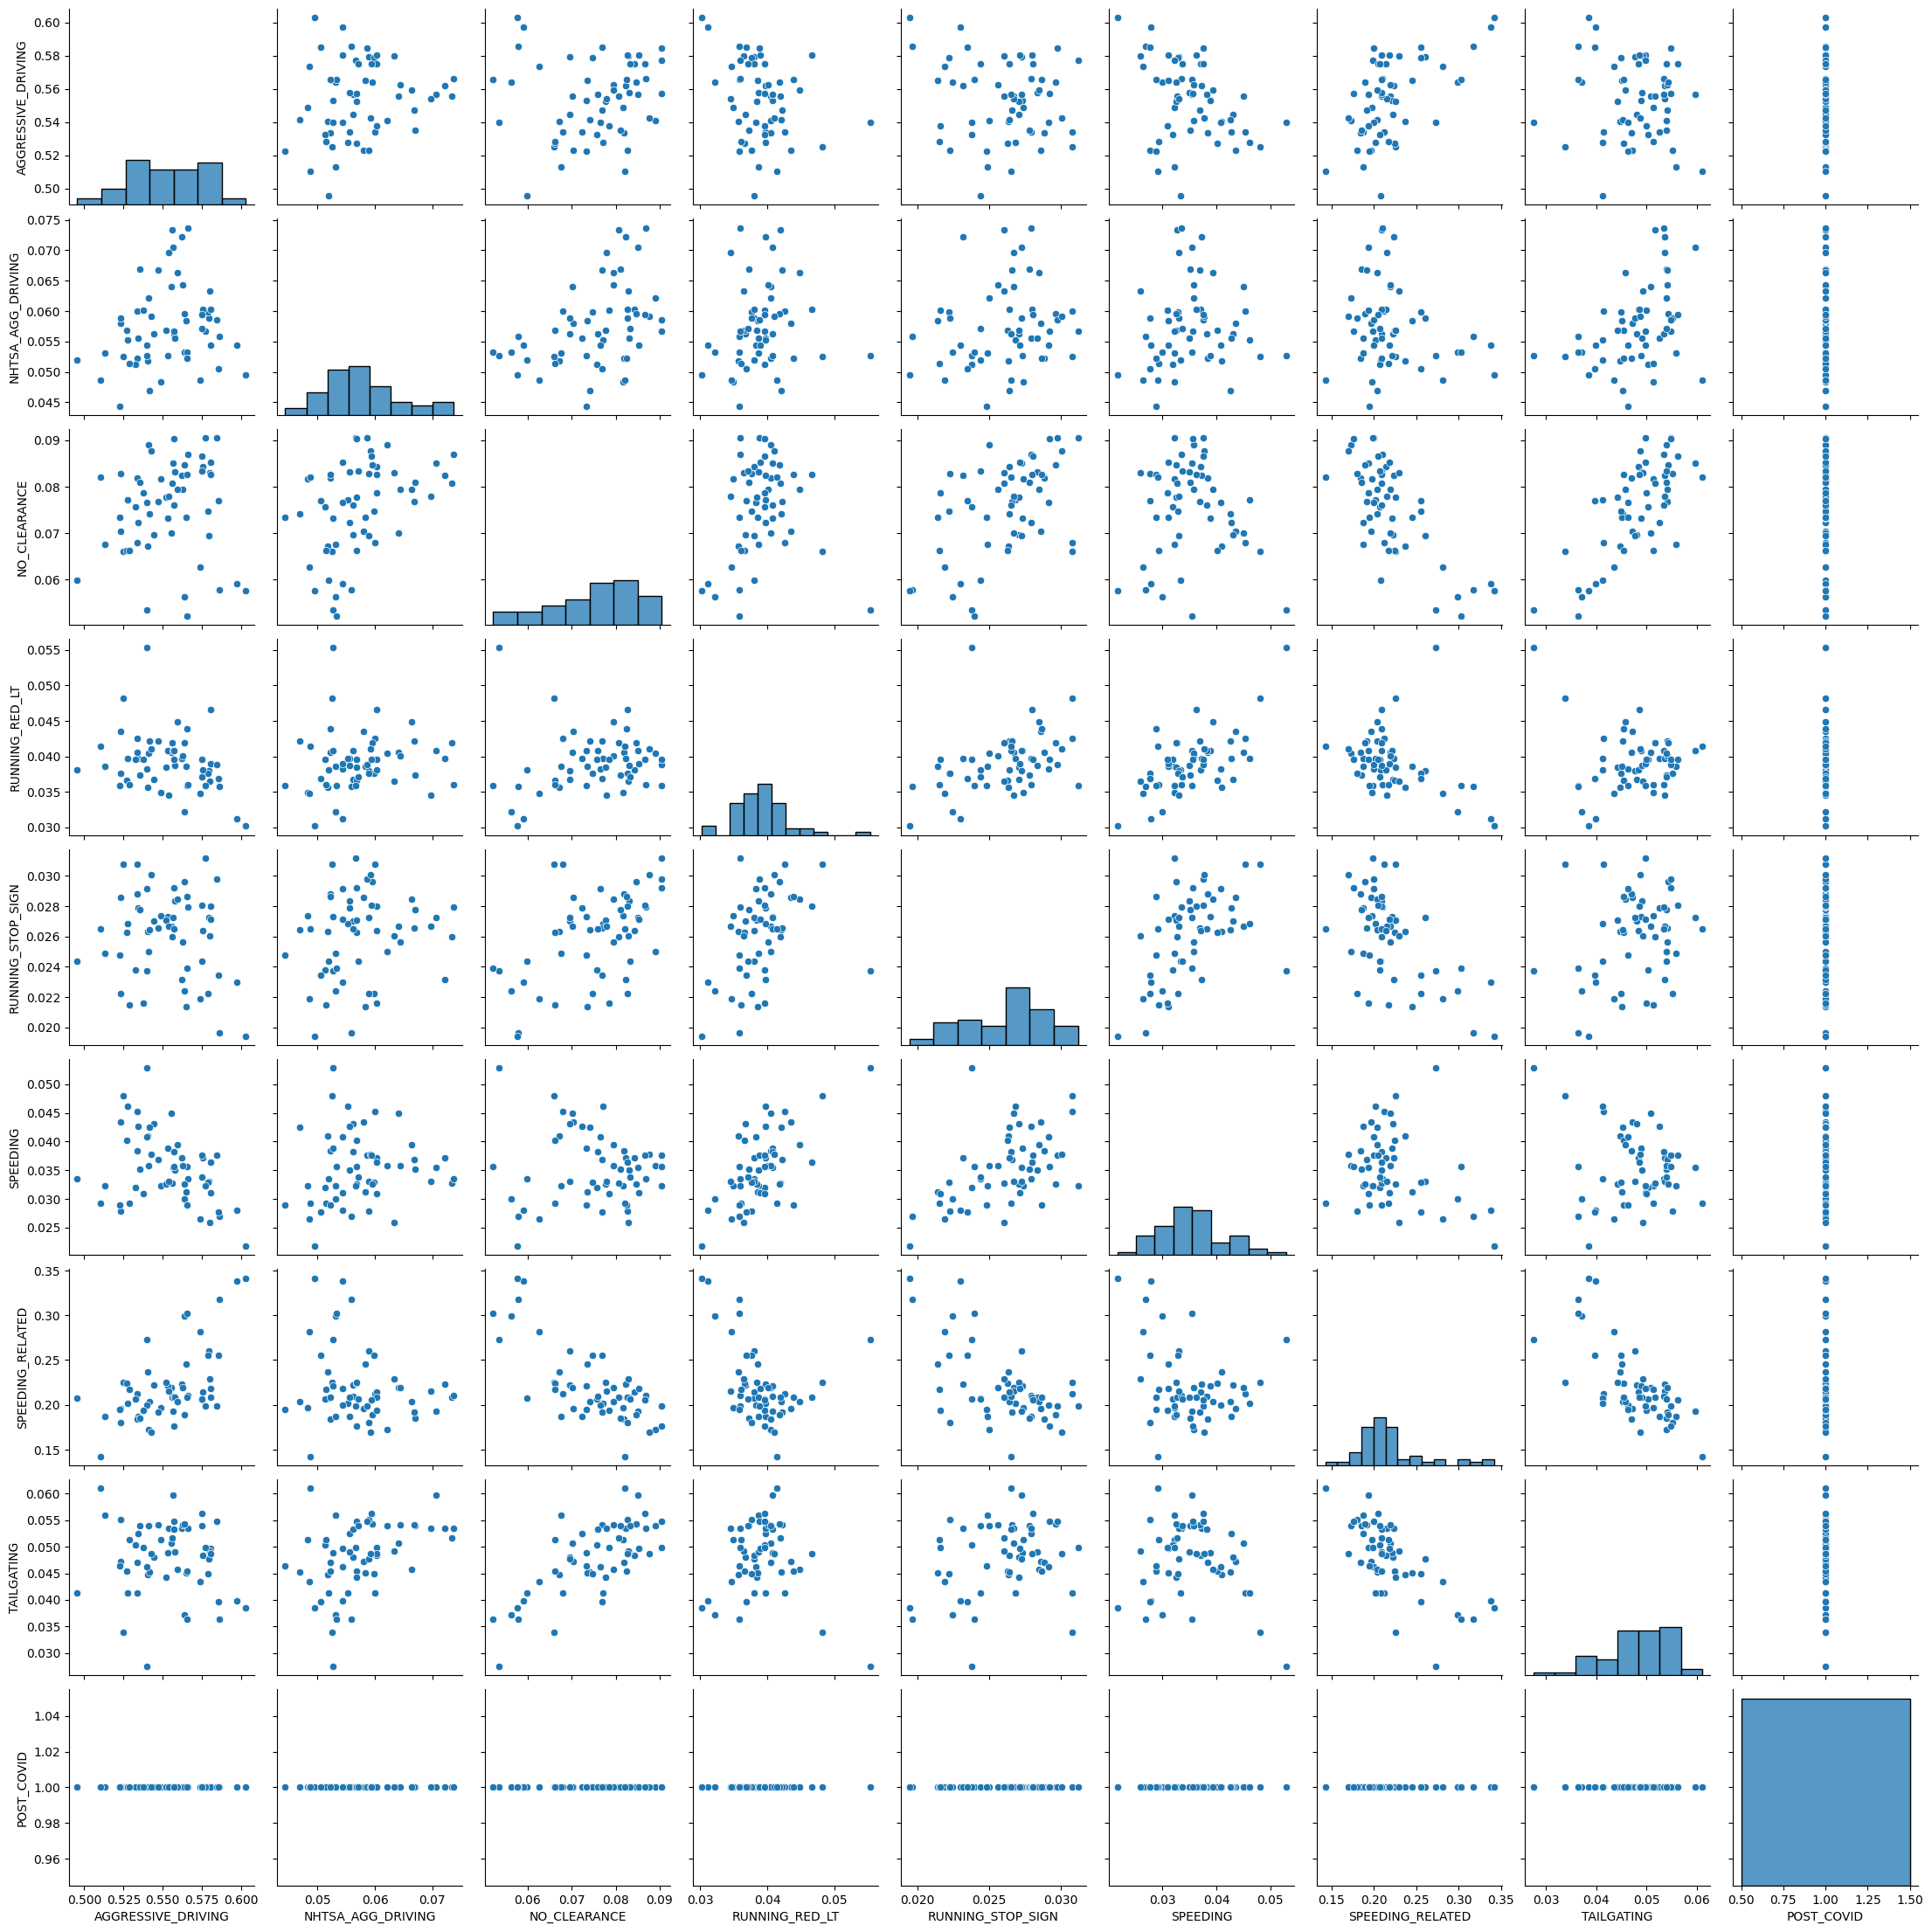

In [16]:
sns.pairplot(post_df)
plt.show()

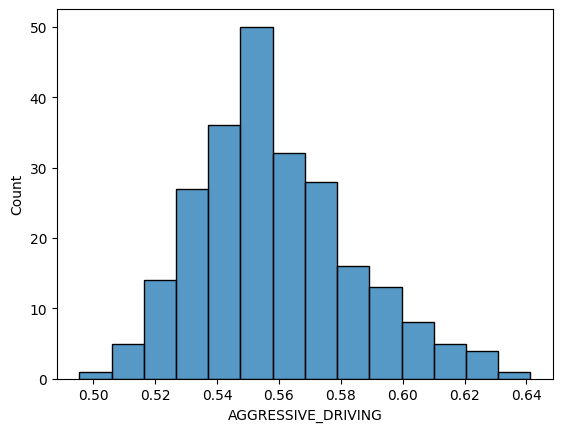

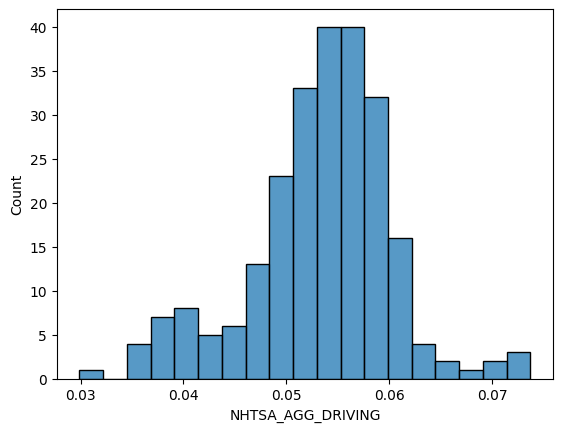

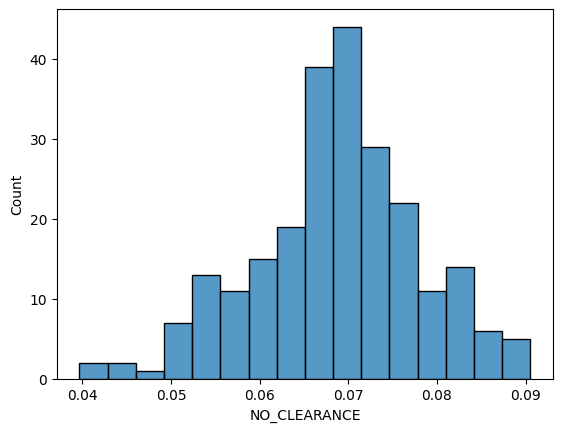

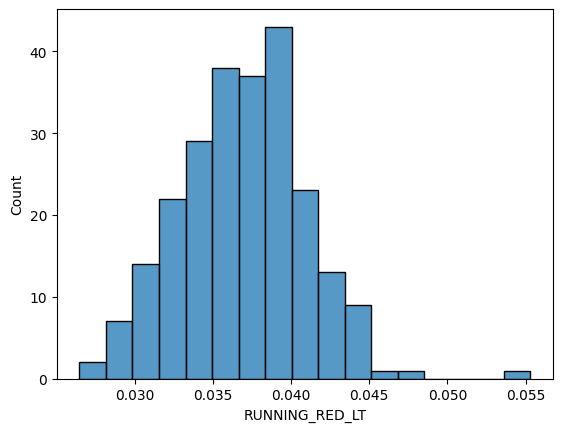

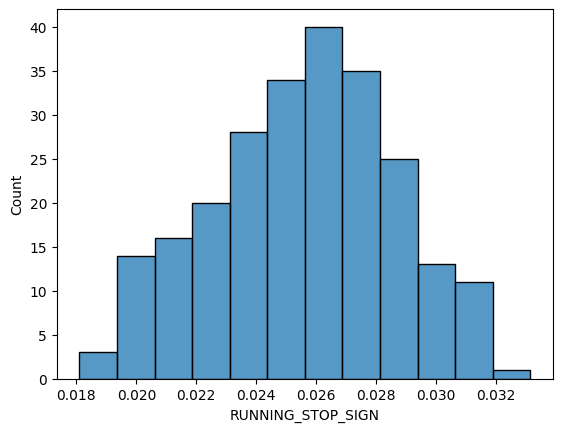

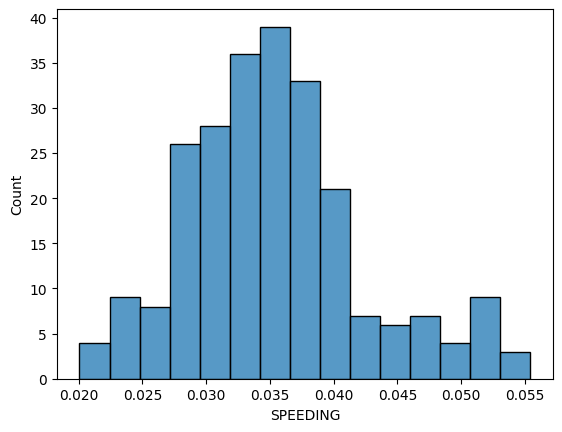

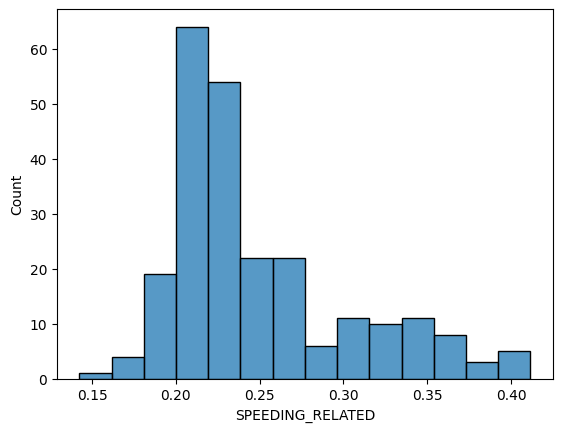

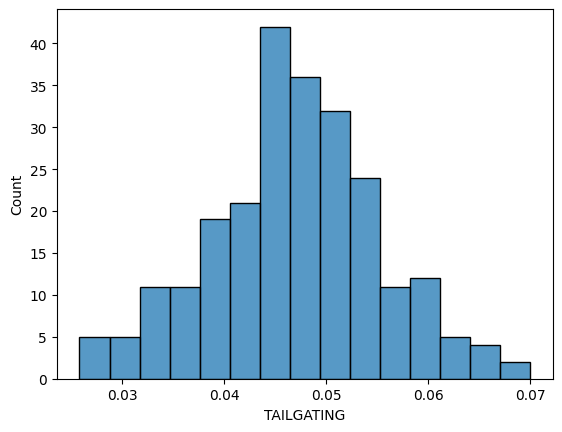

In [17]:
for c in all_cols:
    sns.histplot(data=df, x=c)
    plt.show()

In [18]:
normal_cols = []
not_normal_iter1 = []

for c in all_cols:
    stat, p = normaltest(df[c].to_numpy())

    print(c)
    print(f'Statistic: {stat:.3f}, p-value: {p:.3f}')

    if p > 0.05:
        print('Data appears to be normally distributed')
        normal_cols.append(c)
    else:
        print('Data does not appear to be normally distributed')
        not_normal_iter1.append(c)

    print()

AGGRESSIVE_DRIVING
Statistic: 12.801, p-value: 0.002
Data does not appear to be normally distributed

NHTSA_AGG_DRIVING
Statistic: 14.215, p-value: 0.001
Data does not appear to be normally distributed

NO_CLEARANCE
Statistic: 3.304, p-value: 0.192
Data appears to be normally distributed

RUNNING_RED_LT
Statistic: 10.452, p-value: 0.005
Data does not appear to be normally distributed

RUNNING_STOP_SIGN
Statistic: 5.011, p-value: 0.082
Data appears to be normally distributed

SPEEDING
Statistic: 18.064, p-value: 0.000
Data does not appear to be normally distributed

SPEEDING_RELATED
Statistic: 40.427, p-value: 0.000
Data does not appear to be normally distributed

TAILGATING
Statistic: 0.180, p-value: 0.914
Data appears to be normally distributed



In [19]:
normal_cols

['NO_CLEARANCE', 'RUNNING_STOP_SIGN', 'TAILGATING']

In [20]:
not_normal_iter1

['AGGRESSIVE_DRIVING',
 'NHTSA_AGG_DRIVING',
 'RUNNING_RED_LT',
 'SPEEDING',
 'SPEEDING_RELATED']

In [21]:
for c in not_normal_iter1:
    df[c + '_nlog'] = np.log(df[c])

In [22]:
df.head()

,AGGRESSIVE_DRIVING,NHTSA_AGG_DRIVING,NO_CLEARANCE,RUNNING_RED_LT,RUNNING_STOP_SIGN,SPEEDING,SPEEDING_RELATED,TAILGATING,POST_COVID,AGGRESSIVE_DRIVING_nlog,NHTSA_AGG_DRIVING_nlog,RUNNING_RED_LT_nlog,SPEEDING_nlog,SPEEDING_RELATED_nlog
CRASH_DATE,,,,,,,,,,,,,,
2005-01-01,0.641275,0.050996,0.052749,0.033068,0.024223,0.031474,0.398486,0.032191,0.0,-0.444297,-2.976008,-3.409197,-3.458590,-0.920083
2005-02-01,0.628530,0.050528,0.061175,0.035009,0.027700,0.036723,0.369485,0.031760,0.0,-0.464371,-2.985231,-3.352162,-3.304354,-0.995646
2005-03-01,0.595061,0.055957,0.063656,0.039151,0.026758,0.046005,0.305793,0.039902,0.0,-0.519091,-2.883168,-3.240323,-3.079004,-1.184847
2005-04-01,0.570383,0.058141,0.075505,0.041557,0.029265,0.050044,0.240562,0.045654,0.0,-0.561447,-2.844890,-3.180691,-2.994855,-1.424778
2005-05-01,0.554234,0.058384,0.079875,0.039199,0.030437,0.051651,0.219332,0.044641,0.0,-0.590169,-2.840712,-3.239094,-2.963246,-1.517168


### <a id='nlog'>Natural Log Transformation</a>

In [23]:
not_normal_iter2 = []

for c in not_normal_iter1:
    stat, p = normaltest(df[c + '_nlog'].to_numpy())

    print(c)
    print(f'Statistic: {stat:.3f}, p-value: {p:.3f}')

    if p > 0.05:
        print('Data appears to be normally distributed')
        normal_cols.append(c + '_nlog')
    else:
        print('Data does not appear to be normally distributed')
        not_normal_iter2.append(c)

    print()

AGGRESSIVE_DRIVING
Statistic: 7.679, p-value: 0.022
Data does not appear to be normally distributed

NHTSA_AGG_DRIVING
Statistic: 43.725, p-value: 0.000
Data does not appear to be normally distributed

RUNNING_RED_LT
Statistic: 2.508, p-value: 0.285
Data appears to be normally distributed

SPEEDING
Statistic: 0.643, p-value: 0.725
Data appears to be normally distributed

SPEEDING_RELATED
Statistic: 19.526, p-value: 0.000
Data does not appear to be normally distributed



In [24]:
normal_cols

['NO_CLEARANCE',
 'RUNNING_STOP_SIGN',
 'TAILGATING',
 'RUNNING_RED_LT_nlog',
 'SPEEDING_nlog']

In [25]:
not_normal_iter2

['AGGRESSIVE_DRIVING', 'NHTSA_AGG_DRIVING', 'SPEEDING_RELATED']

### <a id='sqrt'>Square Root Transformation</a>

In [26]:
for c in not_normal_iter2:
    df[c + '_sqrt'] = np.sqrt(df[c])

In [27]:
not_normal_iter3 = []

for c in not_normal_iter2:
    stat, p = normaltest(df[c + '_sqrt'].to_numpy())

    print(c)
    print(f'Statistic: {stat:.3f}, p-value: {p:.3f}')

    if p > 0.05:
        print('Data appears to be normally distributed')
        normal_cols.append(c + '_sqrt')
    else:
        print('Data does not appear to be normally distributed')
        not_normal_iter3.append(c)

    print()

AGGRESSIVE_DRIVING
Statistic: 10.076, p-value: 0.006
Data does not appear to be normally distributed

NHTSA_AGG_DRIVING
Statistic: 26.874, p-value: 0.000
Data does not appear to be normally distributed

SPEEDING_RELATED
Statistic: 29.171, p-value: 0.000
Data does not appear to be normally distributed



In [28]:
not_normal_iter3

['AGGRESSIVE_DRIVING', 'NHTSA_AGG_DRIVING', 'SPEEDING_RELATED']

### <a id='recip'>Reciprocal Transformation</a>

In [29]:
for c in not_normal_iter3:
    df[c + '_recip'] = 1/df[c]

In [30]:
not_normal_iter4 = []

for c in not_normal_iter3:
    stat, p = normaltest(df[c + '_recip'].to_numpy())

    print(c)
    print(f'Statistic: {stat:.3f}, p-value: {p:.3f}')

    if p > 0.05:
        print('Data appears to be normally distributed')
        normal_cols.append(c + '_recip')
    else:
        print('Data does not appear to be normally distributed')
        not_normal_iter4.append(c)

    print()

AGGRESSIVE_DRIVING
Statistic: 3.864, p-value: 0.145
Data appears to be normally distributed

NHTSA_AGG_DRIVING
Statistic: 85.204, p-value: 0.000
Data does not appear to be normally distributed

SPEEDING_RELATED
Statistic: 3.573, p-value: 0.168
Data appears to be normally distributed



In [31]:
not_normal_iter4

['NHTSA_AGG_DRIVING']

### <a id='bxcx'>BoxCox Transformation</a>

In [32]:
best_lambda = []

for c in not_normal_iter4:
    df[c + '_bxcx'] = boxcox(df[c].to_numpy())[0]
    best_lambda.append(boxcox(df[c].to_numpy())[1])

In [33]:
not_normal_iter5 = []

for c in not_normal_iter4:
    stat, p = normaltest(df[c + '_bxcx'].to_numpy())

    print(c)
    print(f'Statistic: {stat:.3f}, p-value: {p:.3f}')

    if p > 0.05:
        print('Data appears to be normally distributed')
        normal_cols.append(c + '_bxcx')
    else:
        print('Data does not appear to be normally distributed')
        not_normal_iter5.append(c)

    print()

NHTSA_AGG_DRIVING
Statistic: 8.655, p-value: 0.013
Data does not appear to be normally distributed



In [34]:
normal_cols

['NO_CLEARANCE',
 'RUNNING_STOP_SIGN',
 'TAILGATING',
 'RUNNING_RED_LT_nlog',
 'SPEEDING_nlog',
 'AGGRESSIVE_DRIVING_recip',
 'SPEEDING_RELATED_recip']

### <a id='nhtsa'>Special Handling of NHTSA_AGG_DRIVING</a>

In [35]:
trx = ['nlog', 'sqrt', 'recip', 'bxcx']

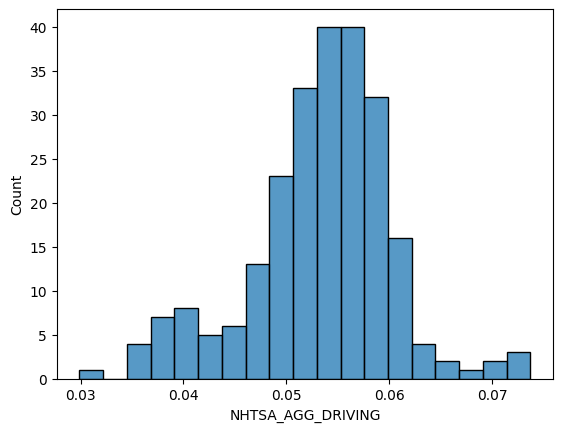

In [36]:
sns.histplot(data=df, x='NHTSA_AGG_DRIVING')
plt.show()

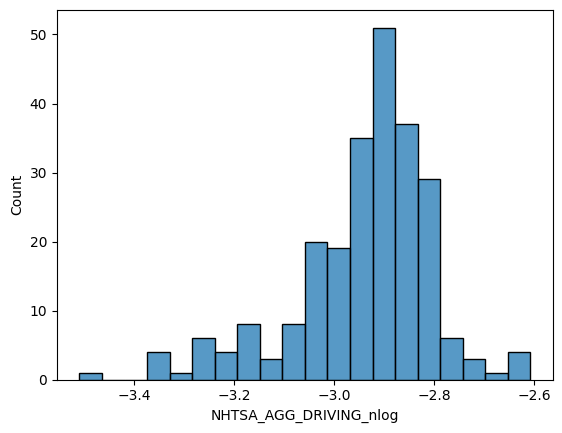

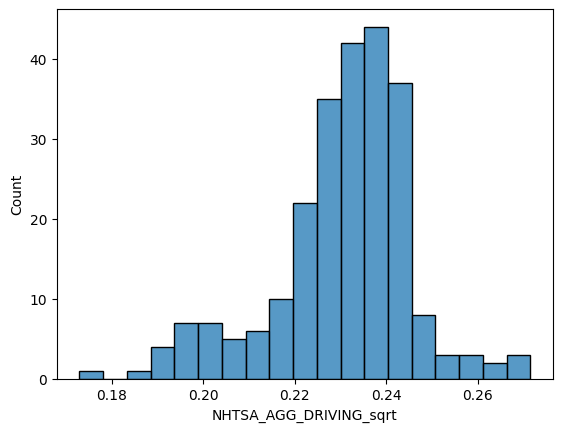

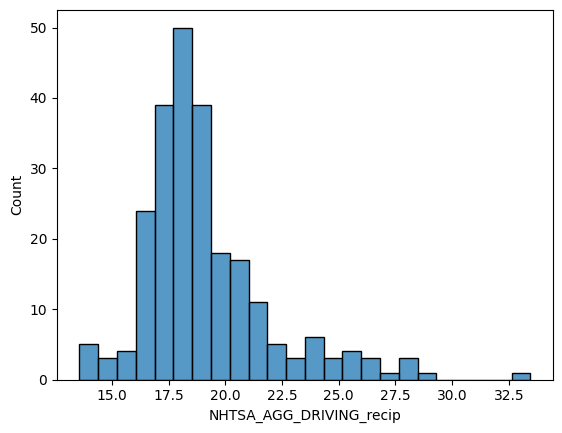

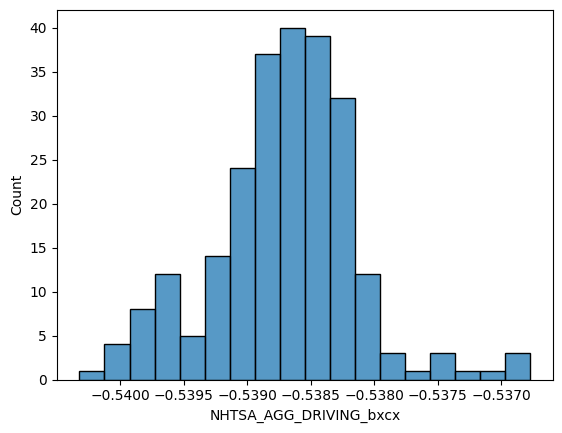

In [37]:
for t in trx:
    sns.histplot(data=df, x='NHTSA_AGG_DRIVING_' + t)
    plt.show()

In [38]:
df[c + '_nlog_recip'] = np.log(df[c + '_recip'])

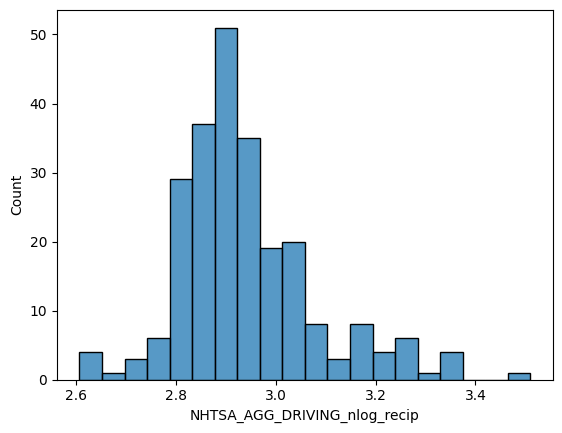

In [39]:
sns.histplot(data=df, x='NHTSA_AGG_DRIVING_nlog_recip')
plt.show()

In [40]:
df[c + '_sqrt_recip'] = np.sqrt(df[c + '_recip'])

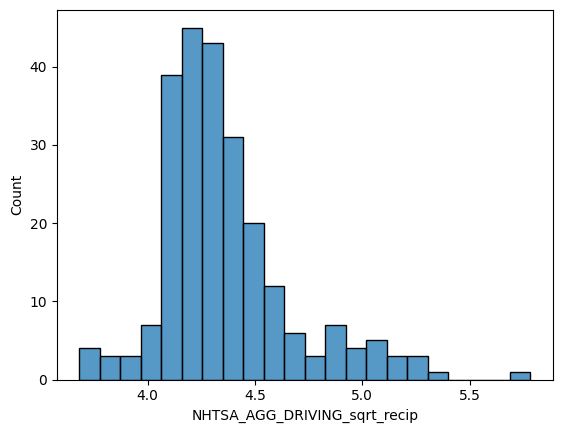

In [41]:
sns.histplot(data=df, x='NHTSA_AGG_DRIVING_sqrt_recip')
plt.show()

In [42]:
df[c + '_bxcx_recip'] = boxcox(df[c + '_recip'].to_numpy())[0]

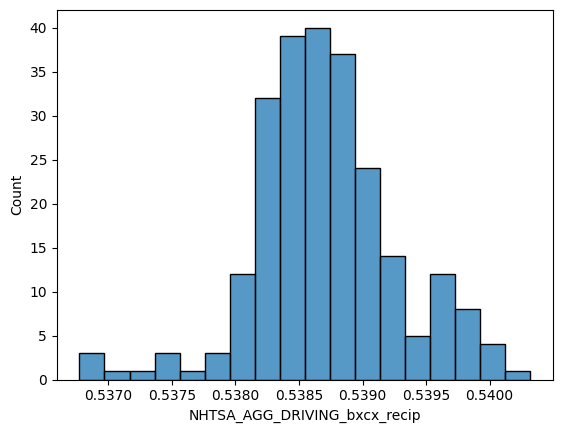

In [43]:
sns.histplot(data=df, x='NHTSA_AGG_DRIVING_bxcx_recip')
plt.show()

In [44]:
df[c + '_log10'] = np.log10(df[c])

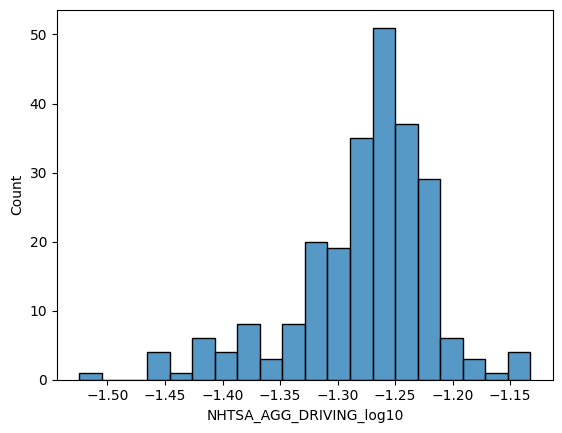

In [45]:
sns.histplot(data=df, x='NHTSA_AGG_DRIVING_log10')
plt.show()

In [46]:
#transformed_data, lmbda = yeojohnson(data)
df[c + '_yeoj'] = yeojohnson(df[c].to_numpy())[0]

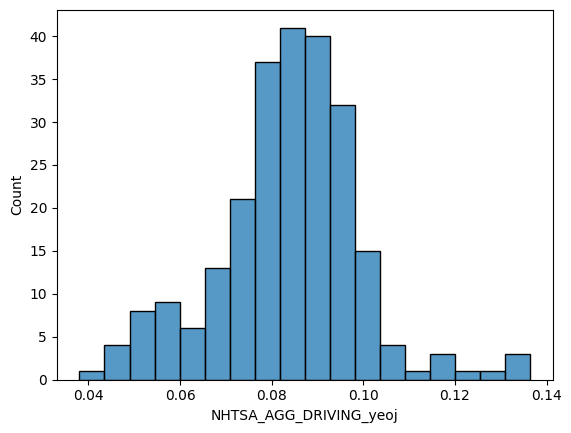

In [47]:
sns.histplot(data=df, x='NHTSA_AGG_DRIVING_yeoj')
plt.show()

In [48]:
stat, p = normaltest(df['NHTSA_AGG_DRIVING_yeoj'].to_numpy())

print(f'Statistic: {stat:.3f}, p-value: {p:.3f}')

if p > 0.05:
    print('Data appears to be normally distributed')
    normal_cols.append('NHTSA_AGG_DRIVING_yeoj')
else:
    print('Data does not appear to be normally distributed')
    not_normal_iter5.append('NHTSA_AGG_DRIVING_yeoj')

print()

Statistic: 8.884, p-value: 0.012
Data does not appear to be normally distributed



In [49]:
#transformed_data, lmbda = yeojohnson(data)
df[c + '_yeoj_sqrt'] = yeojohnson(df[c + '_sqrt'].to_numpy())[0]

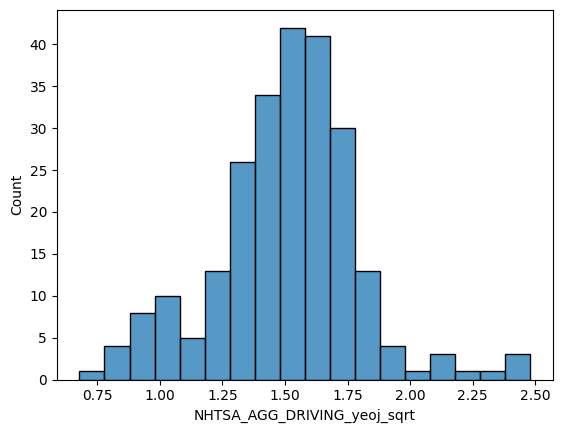

In [50]:
sns.histplot(data=df, x='NHTSA_AGG_DRIVING_yeoj_sqrt')
plt.show()

In [51]:
stat, p = normaltest(df['NHTSA_AGG_DRIVING_yeoj_sqrt'].to_numpy())

print(f'Statistic: {stat:.3f}, p-value: {p:.3f}')

if p > 0.05:
    print('Data appears to be normally distributed')
    normal_cols.append('NHTSA_AGG_DRIVING_yeoj_sqrt')
else:
    print('Data does not appear to be normally distributed')
    not_normal_iter5.append('NHTSA_AGG_DRIVING_yeoj_sqrt')

print()

Statistic: 8.986, p-value: 0.011
Data does not appear to be normally distributed



In [52]:
nhtsa_trx = ['nlog','sqrt','recip','bxcx','log10','yeoj','yeoj_sqrt']

In [53]:
stat, p = normaltest(df['NHTSA_AGG_DRIVING'].to_numpy())

print(f'Statistic: {stat:.3f}, p-value: {p:.3f}')

if p > 0.05:
    print('Data appears to be normally distributed')
else:
    print('Data does not appear to be normally distributed')

print()

Statistic: 14.215, p-value: 0.001
Data does not appear to be normally distributed



In [54]:
for t in nhtsa_trx:
    stat, p = normaltest(df['NHTSA_AGG_DRIVING_' + t].to_numpy())

    print(t)
    print(f'Statistic: {stat:.3f}, p-value: {p:.3f}')

    if p > 0.05:
        print('Data appears to be normally distributed')
    else:
        print('Data does not appear to be normally distributed')

    print()

nlog
Statistic: 43.725, p-value: 0.000
Data does not appear to be normally distributed

sqrt
Statistic: 26.874, p-value: 0.000
Data does not appear to be normally distributed

recip
Statistic: 85.204, p-value: 0.000
Data does not appear to be normally distributed

bxcx
Statistic: 8.655, p-value: 0.013
Data does not appear to be normally distributed

log10
Statistic: 43.725, p-value: 0.000
Data does not appear to be normally distributed

yeoj
Statistic: 8.884, p-value: 0.012
Data does not appear to be normally distributed

yeoj_sqrt
Statistic: 8.986, p-value: 0.011
Data does not appear to be normally distributed



In [55]:
normal_cols.append('NHTSA_AGG_DRIVING_bxcx')

In [56]:
normal_cols

['NO_CLEARANCE',
 'RUNNING_STOP_SIGN',
 'TAILGATING',
 'RUNNING_RED_LT_nlog',
 'SPEEDING_nlog',
 'AGGRESSIVE_DRIVING_recip',
 'SPEEDING_RELATED_recip',
 'NHTSA_AGG_DRIVING_bxcx']

### <a id='final'>Final BoxCox Transformation All Columns</a>

In [57]:
best_lambda = []

for c in all_cols:
    df[c + '_bxcx'] = boxcox(df[c].to_numpy())[0]
    best_lambda.append(boxcox(df[c].to_numpy())[1])

In [58]:
normal_cols = []
not_normal_iter1 = []

for c in all_cols:
    stat, p = normaltest(df[c + '_bxcx'].to_numpy())

    print(c)
    print(f'Statistic: {stat:.3f}, p-value: {p:.3f}')

    if p > 0.05:
        print('Data appears to be normally distributed')
        normal_cols.append(c)
    else:
        print('Data does not appear to be normally distributed')
        not_normal_iter1.append(c + '_bxcx')

    print()

AGGRESSIVE_DRIVING
Statistic: 0.003, p-value: 0.998
Data appears to be normally distributed

NHTSA_AGG_DRIVING
Statistic: 8.655, p-value: 0.013
Data does not appear to be normally distributed

NO_CLEARANCE
Statistic: 0.100, p-value: 0.951
Data appears to be normally distributed

RUNNING_RED_LT
Statistic: 2.743, p-value: 0.254
Data appears to be normally distributed

RUNNING_STOP_SIGN
Statistic: 4.657, p-value: 0.097
Data appears to be normally distributed

SPEEDING
Statistic: 0.596, p-value: 0.742
Data appears to be normally distributed

SPEEDING_RELATED
Statistic: 1.719, p-value: 0.423
Data appears to be normally distributed

TAILGATING
Statistic: 0.039, p-value: 0.981
Data appears to be normally distributed

